In [1]:
# AIM
# Mean and median filter for image noise removal with different stride and kernel size
import numpy as np
import cv2
import matplotlib.pyplot as plt

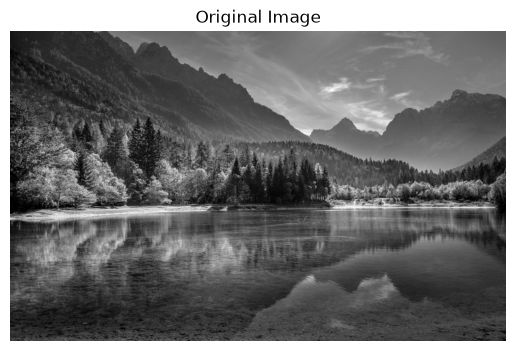

In [ ]:
# Load Dog image
image = cv2.imread("D:\Sem-7\CV-LAB\wallpaperflare.com_wallpaper (2).jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

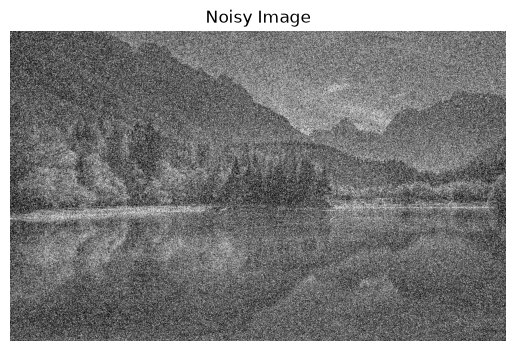

In [3]:
# Add Salt and Pepper Noise
def add_salt_pepper_noise(image, probability=0.1):
    noisy = image.copy()
    random_matrix = np.random.rand(*image.shape)
    noisy[random_matrix < probability / 2] = 0
    noisy[random_matrix > 1 - (probability / 2)] = 255
    return noisy

noisy_image = add_salt_pepper_noise(image, probability=0.5)

plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.show()

In [4]:
# Median Filter Function
def median_filter(image, kernel_size=3, stride=1):
    h, w = image.shape
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    
    out_h = (h - kernel_size + 2 * pad) // stride + 1
    out_w = (w - kernel_size + 2 * pad) // stride + 1
    
    output = np.zeros((out_h, out_w), dtype=image.dtype)
    
    for i in range(out_h):
        for j in range(out_w):
            window = padded[i*stride : i*stride + kernel_size, j*stride : j*stride + kernel_size]
            output[i, j] = np.median(window)
            
    return output

In [5]:
def mean_filter(image, k=3, s=1):
    h, w = image.shape
    pad = k // 2
    padded = np.pad(image, pad, mode='reflect')

    out_h = (h - k + 2*pad) // s + 1
    out_w = (w - k + 2*pad) // s + 1

    og = np.zeros((out_h, out_w), dtype=image.dtype)

    for i in range(out_h):
        for j in range(out_w):
            window = padded[i * s: i * s + k, j * s: j * s + k]
            og[i, j] = np.mean(window)
    return og

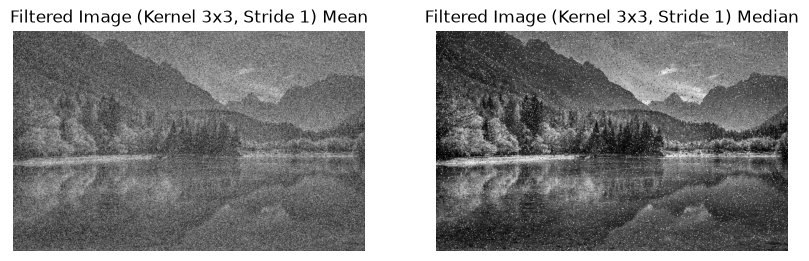

In [6]:
# Run median_filter function and display visual output using matplotlib
filtered_image_median = median_filter(noisy_image, kernel_size=3, stride=1)
filtered_image_mean = mean_filter(noisy_image, k=3, s=1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(filtered_image_mean, cmap="gray")
plt.title("Filtered Image (Kernel 3x3, Stride 1) Mean")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_median, cmap="gray")
plt.title("Filtered Image (Kernel 3x3, Stride 1) Median")
plt.axis("off")

plt.show()

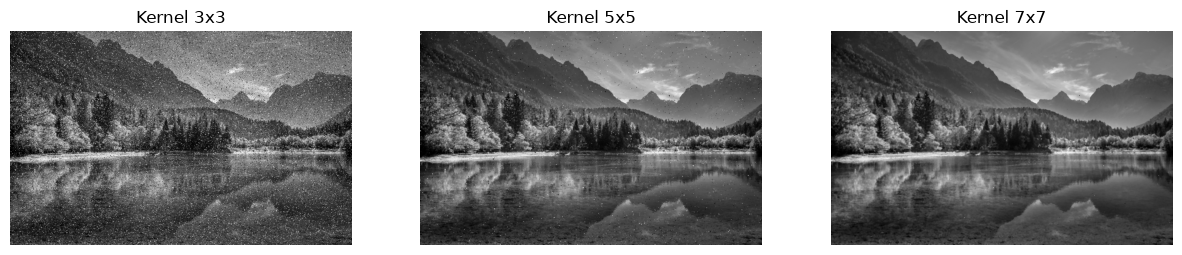

In [7]:
# Apply median filter with kernel sizes: 3x3, 5x5, 7x7
k3 = median_filter(noisy_image, kernel_size=3, stride=1)
k5 = median_filter(noisy_image, kernel_size=5, stride=1)
k7 = median_filter(noisy_image, kernel_size=7, stride=1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(k3, cmap="gray")
plt.title("Kernel 3x3")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(k5, cmap="gray")
plt.title("Kernel 5x5")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(k7, cmap="gray")
plt.title("Kernel 7x7")
plt.axis("off")

plt.show()

Stride 1 Shape: (1200, 1920)
Stride 2 Shape: (600, 960)
Stride 3 Shape: (400, 640)


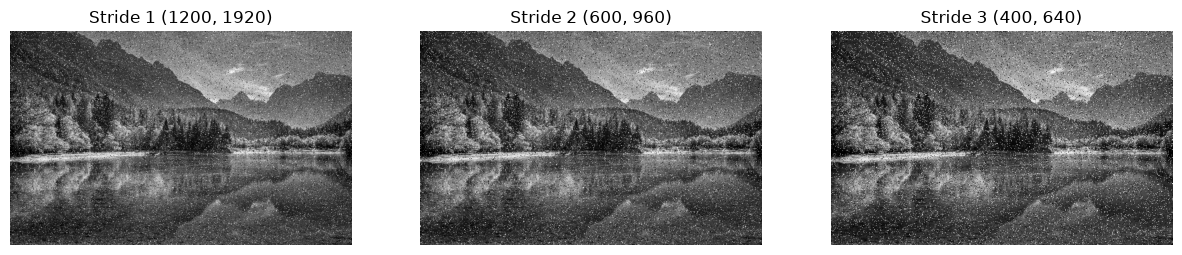

In [8]:
# Apply median filter with stride sizes: 1, 2, 3
s1 = median_filter(noisy_image, kernel_size=3, stride=1)
s2 = median_filter(noisy_image, kernel_size=3, stride=2)
s3 = median_filter(noisy_image, kernel_size=3, stride=3)

print("Stride 1 Shape:", s1.shape)
print("Stride 2 Shape:", s2.shape)
print("Stride 3 Shape:", s3.shape)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(s1, cmap="gray")
plt.title(f"Stride 1 {s1.shape}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(s2, cmap="gray")
plt.title(f"Stride 2 {s2.shape}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(s3, cmap="gray")
plt.title(f"Stride 3 {s3.shape}")
plt.axis("off")

plt.show()

In [ ]:
# Gaussian Filter Function

def gaussian_filter(image, kernel_size=3, sigma=1.0, stride=1):
    if kernel_size < 1 or kernel_size % 2 == 0:
        raise ValueError("kernel_size must be a positive odd number")
    if sigma <= 0:
        raise ValueError("sigma must be greater than 0")
    if stride < 1:
        raise ValueError("stride must be a positive integer")

    radius = kernel_size // 2
    axis = np.arange(-radius, radius + 1)
    x, y = np.meshgrid(axis, axis)
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()

    height, width = image.shape
    padded = np.pad(image, radius, mode="reflect")
    output_height = (height - kernel_size + 2 * radius) // stride + 1
    output_width = (width - kernel_size + 2 * radius) // stride + 1
    output = np.zeros((output_height, output_width), dtype=np.float32)

    for i in range(output_height):
        for j in range(output_width):
            window = padded[
                i * stride:i * stride + kernel_size,
                j * stride:j * stride + kernel_size
            ]
            output[i, j] = np.sum(window * kernel)

    return np.clip(output, 0, 255).astype(image.dtype)


# Apply Gaussian filtering with different kernel sizes

gaussian_3 = gaussian_filter(noisy_image, kernel_size=3, sigma=1.0, stride=1)
gaussian_5 = gaussian_filter(noisy_image, kernel_size=5, sigma=1.0, stride=1)
gaussian_7 = gaussian_filter(noisy_image, kernel_size=7, sigma=1.0, stride=1)

plt.figure(figsize=(15, 5))
for index, (filtered, title) in enumerate([
    (gaussian_3, "Gaussian 3x3"),
    (gaussian_5, "Gaussian 5x5"),
    (gaussian_7, "Gaussian 7x7")
], start=1):
    plt.subplot(1, 3, index)
    plt.imshow(filtered, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()